In [1]:
import warnings
from arivale_data_interface import get_snapshot
import pandas as pd
import numpy as np
import scipy
import json

warnings.simplefilter("ignore")

#import the final master sleep_merged df and the features_dict

sleep_merged = pd.read_csv('../working_df/sleep_merged_sleep_meds_included_11_20_2025.csv', dtype={'public_client_id': object})

with open('../working_df/features_dict.json', 'r') as f:
    features_dict = json.load(f)

### Rationale for converting the Likert scale responses to continuous for OLS regression rather than ordinal regression:
- https://www.statalist.org/forums/forum/general-stata-discussion/general/1512638-ols-for-likert-scale
- The happiness questionnaires can be combined into an index / summary score (see Arivale documentation). This scoring implicitly assumes that the individual questions are already continuous/interval rather than ordinal categorical.

In [2]:
import sys
import os

# Import my regression and plotting functions python file to use the functions from that
sys.path.append(os.path.abspath("../regression_and_plotting_functions"))
from regression_and_plotting_functions import *

# Merge on the happiness questionnaire

In [4]:
happiness = get_snapshot('assessments_happiness')

In [5]:
happiness.columns

Index(['public_client_id', 'vendor', 'days_in_program',
       'days_since_first_call', 'days_since_first_draw', 'month', 'weekday',
       'season', 'assessment:satisfaction::enum',
       'assessment:satisfaction:cheerful_effect:enum',
       'assessment:satisfaction:dislike_way_i_am:enum',
       'assessment:satisfaction:find_beauty:enum',
       'assessment:satisfaction:find_time:enum',
       'assessment:satisfaction:fun_with_people:enum',
       'assessment:satisfaction:gap:enum',
       'assessment:satisfaction:good_influence:enum',
       'assessment:satisfaction:have_energy:enum',
       'assessment:satisfaction:intense_interest_in_others:enum',
       'assessment:satisfaction:involved:enum',
       'assessment:satisfaction:joy_and_elation:enum',
       'assessment:satisfaction:laugh_a_lot:enum',
       'assessment:satisfaction:life_is_good:enum',
       'assessment:satisfaction:life_is_rewarding:enum',
       'assessment:satisfaction:make_decisions:enum',
       'assessment:s

In [6]:
happiness.response_pct.describe()

count    5914.000000
mean       98.563882
std         9.505330
min         3.400000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: response_pct, dtype: float64

In [7]:
happiness.shape

(5914, 39)

In [8]:
# only keep data points with 100% response rate
happiness = happiness[happiness.response_pct == 100]

In [9]:
happiness.shape

(5744, 39)

In [10]:
# Clean up the column names
def clean_column_name(col):
    col = col.removeprefix("assessment:")  # Remove 'assessment:'
    col = col.removesuffix(":enum")  # Remove ':enum'
    col = col.replace(":", "_")  # Replace colons with underscores
    return col

# Apply renaming
happiness.columns = [clean_column_name(col) for col in happiness.columns]

In [11]:
# fix column 8 so the name doesn't throw errors later
happiness.rename(columns={'satisfaction_': 'satisfaction'}, inplace=True)

In [12]:
happiness.columns

Index(['public_client_id', 'vendor', 'days_in_program',
       'days_since_first_call', 'days_since_first_draw', 'month', 'weekday',
       'season', 'satisfaction', 'satisfaction_cheerful_effect',
       'satisfaction_dislike_way_i_am', 'satisfaction_find_beauty',
       'satisfaction_find_time', 'satisfaction_fun_with_people',
       'satisfaction_gap', 'satisfaction_good_influence',
       'satisfaction_have_energy', 'satisfaction_intense_interest_in_others',
       'satisfaction_involved', 'satisfaction_joy_and_elation',
       'satisfaction_laugh_a_lot', 'satisfaction_life_is_good',
       'satisfaction_life_is_rewarding', 'satisfaction_make_decisions',
       'satisfaction_mentally_alert', 'satisfaction_most_things_amusing',
       'satisfaction_no_happy_memories', 'satisfaction_not_attractive',
       'satisfaction_not_healthy', 'satisfaction_not_in_control',
       'satisfaction_not_optimistic', 'satisfaction_purpose',
       'satisfaction_rarely_rested', 'satisfaction_take_on_

In [13]:
# define the happiness features
happiness_features = happiness.columns[8:-2].tolist()
happiness_features

['satisfaction',
 'satisfaction_cheerful_effect',
 'satisfaction_dislike_way_i_am',
 'satisfaction_find_beauty',
 'satisfaction_find_time',
 'satisfaction_fun_with_people',
 'satisfaction_gap',
 'satisfaction_good_influence',
 'satisfaction_have_energy',
 'satisfaction_intense_interest_in_others',
 'satisfaction_involved',
 'satisfaction_joy_and_elation',
 'satisfaction_laugh_a_lot',
 'satisfaction_life_is_good',
 'satisfaction_life_is_rewarding',
 'satisfaction_make_decisions',
 'satisfaction_mentally_alert',
 'satisfaction_most_things_amusing',
 'satisfaction_no_happy_memories',
 'satisfaction_not_attractive',
 'satisfaction_not_healthy',
 'satisfaction_not_in_control',
 'satisfaction_not_optimistic',
 'satisfaction_purpose',
 'satisfaction_rarely_rested',
 'satisfaction_take_on_anything',
 'satisfaction_very_happy',
 'satisfaction_well_satisfied',
 'satisfaction_world_is_a_bad_place']

In [14]:
len(happiness_features)

29

In [15]:
for i in range(len(happiness_features)):
    print('')
    print('')
    print(happiness_features[i], i)
    print(sorted(happiness[happiness_features[i]].dropna().unique()))



satisfaction 0
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_cheerful_effect 1
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_dislike_way_i_am 2
['(1) Strongly Agree', '(2) Moderately Agree', '(3) Slightly Agree', '(4) Slightly Disagree', '(5) Moderately Disagree', '(6) Strongly Disagree']


satisfaction_find_beauty 3
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_find_time 4
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_fun_with_people 5
['(1) Strongly Agree', '(2) Moderately Agree', '(3) Slightly Agree', '(4) Slightly Disagree', '(5

In [16]:
reverse_likert_scales = [2, 5, 6, 15, 18, 19, 20, 21, 22, 23, 24, 28]

In [17]:
# Some of the likert scales are flipped! For instance question 5 'fun with people'
# (1) is Strongly Agree but other questions like q4 (1) is Strongly Disagree
# Fix the responses so they are all the same order
def flip_likert_string(x):
    if isinstance(x, str):
        original_num = int(x[1])
        flipped_num = {1:6, 2:5, 3:4, 4:3, 5:2, 6:1}[original_num]
        return f'({flipped_num}){x[3:]}'
    else:
        return x

for feature in [happiness_features[i] for i in reverse_likert_scales]:
    happiness[feature] = happiness[feature].apply(flip_likert_string)

In [18]:
for i in range(len(happiness_features)):
    print('')
    print('')
    print(happiness_features[i], i)
    print(sorted(happiness[happiness_features[i]].dropna().unique()))



satisfaction 0
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_cheerful_effect 1
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_dislike_way_i_am 2
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_find_beauty 3
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_find_time 4
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree', '(5) Moderately Agree', '(6) Strongly Agree']


satisfaction_fun_with_people 5
['(1) Strongly Disagree', '(2) Moderately Disagree', '(3) Slightly Disagree', '(4) Slightly Agree

In [19]:
happiness[happiness_features[0]].value_counts()

satisfaction
(5) Moderately Agree       2293
(4) Slightly Agree         1335
(6) Strongly Agree         1069
(3) Slightly Disagree       599
(2) Moderately Disagree     341
(1) Strongly Disagree       107
Name: count, dtype: int64

### Convert to continuous integers

In [20]:
# Now clean up the responses so that they are numeric

def extract_numeric_value(response):
    num = pd.to_numeric(response.str.extract(r"\((\d+)\)")[0], errors="raise")  # Extract number inside parentheses
    return num

# Loop through the happiness columns to convert to numeric
for col in happiness_features:
    happiness[f'{col}_numeric'] = extract_numeric_value(happiness[col])

happiness_features_numeric = [f'{feature}_numeric' for feature in happiness_features]

In [21]:
happiness[happiness_features]

,satisfaction,satisfaction_cheerful_effect,satisfaction_dislike_way_i_am,satisfaction_find_beauty,satisfaction_find_time,satisfaction_fun_with_people,satisfaction_gap,satisfaction_good_influence,satisfaction_have_energy,satisfaction_intense_interest_in_others,...,satisfaction_not_attractive,satisfaction_not_healthy,satisfaction_not_in_control,satisfaction_not_optimistic,satisfaction_purpose,satisfaction_rarely_rested,satisfaction_take_on_anything,satisfaction_very_happy,satisfaction_well_satisfied,satisfaction_world_is_a_bad_place
0,(3) Slightly Disagree,(2) Moderately Disagree,(5) Moderately Agree,(6) Strongly Agree,(1) Strongly Disagree,(2) Moderately Disagree,(5) Moderately Agree,(5) Moderately Agree,(2) Moderately Disagree,(4) Slightly Agree,...,(5) Moderately Agree,(4) Slightly Agree,(5) Moderately Agree,(4) Slightly Agree,(2) Moderately Disagree,(2) Moderately Disagree,(2) Moderately Disagree,(3) Slightly Disagree,(2) Moderately Disagree,(3) Slightly Disagree
1,(6) Strongly Agree,(5) Moderately Agree,(5) Moderately Agree,(6) Strongly Agree,(3) Slightly Disagree,(2) Moderately Disagree,(4) Slightly Agree,(5) Moderately Agree,(4) Slightly Agree,(5) Moderately Agree,...,(2) Moderately Disagree,(4) Slightly Agree,(4) Slightly Agree,(1) Strongly Disagree,(1) Strongly Disagree,(2) Moderately Disagree,(5) Moderately Agree,(6) Strongly Agree,(4) Slightly Agree,(1) Strongly Disagree
2,(6) Strongly Agree,(5) Moderately Agree,(5) Moderately Agree,(6) Strongly Agree,(6) Strongly Agree,(2) Moderately Disagree,(6) Strongly Agree,(6) Strongly Agree,(1) Strongly Disagree,(6) Strongly Agree,...,(5) Moderately Agree,(5) Moderately Agree,(6) Strongly Agree,(6) Strongly Agree,(2) Moderately Disagree,(6) Strongly Agree,(2) Moderately Disagree,(1) Strongly Disagree,(1) Strongly Disagree,(5) Moderately Agree
3,(4) Slightly Agree,(5) Moderately Agree,(1) Strongly Disagree,(5) Moderately Agree,(5) Moderately Agree,(2) Moderately Disagree,(2) Moderately Disagree,(5) Moderately Agree,(5) Moderately Agree,(4) Slightly Agree,...,(2) Moderately Disagree,(2) Moderately Disagree,(1) Strongly Disagree,(1) Strongly Disagree,(1) Strongly Disagree,(2) Moderately Disagree,(5) Moderately Agree,(6) Strongly Agree,(6) Strongly Agree,(2) Moderately Disagree
4,(3) Slightly Disagree,(4) Slightly Agree,(5) Moderately Agree,(5) Moderately Agree,(1) Strongly Disagree,(1) Strongly Disagree,(5) Moderately Agree,(4) Slightly Agree,(3) Slightly Disagree,(3) Slightly Disagree,...,(4) Slightly Agree,(5) Moderately Agree,(4) Slightly Agree,(2) Moderately Disagree,(5) Moderately Agree,(5) Moderately Agree,(2) Moderately Disagree,(2) Moderately Disagree,(2) Moderately Disagree,(2) Moderately Disagree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5909,(5) Moderately Agree,(5) Moderately Agree,(2) Moderately Disagree,(6) Strongly Agree,(4) Slightly Agree,(2) Moderately Disagree,(3) Slightly Disagree,(5) Moderately Agree,(4) Slightly Agree,(5) Moderately Agree,...,(4) Slightly Agree,(3) Slightly Disagree,(2) Moderately Disagree,(2) Moderately Disagree,(3) Slightly Disagree,(3) Slightly Disagree,(5) Moderately Agree,(4) Slightly Agree,(4) Slightly Agree,(4) Slightly Agree
5910,(4) Slightly Agree,(4) Slightly Agree,(6) Strongly Agree,(6) Strongly Agree,(2) Moderately Disagree,(1) Strongly Disagree,(5) Moderately Agree,(4) Slightly Agree,(2) Moderately Disagree,(6) Strongly Agree,...,(5) Moderately Agree,(6) Strongly Agree,(5) Moderately Agree,(3) Slightly Disagree,(2) Moderately Disagree,(6) Strongly Agree,(4) Slightly Agree,(4) Slightly Agree,(4) Slightly Agree,(5) Moderately Agree
5911,(4) Slightly Agree,(4) Slightly Agree,(2) Moderately Disagree,(5) Moderately Agree,(5) Moderately Agree,(1) Strongly Disagree,(6) Strongly Agree,(5) Moderately Agree,(3) Slightly Disagree,(3) Slightly Disagree,...,(3) Slightly Disagree,(4) Slightly Agree,(1) Strongly Disagree,(1) Strongly Disagree,(1) Strongly Disagree,(2) Moderately Disagree,(5) Moderate

In [22]:
happiness[happiness_features_numeric]

,satisfaction_numeric,satisfaction_cheerful_effect_numeric,satisfaction_dislike_way_i_am_numeric,satisfaction_find_beauty_numeric,satisfaction_find_time_numeric,satisfaction_fun_with_people_numeric,satisfaction_gap_numeric,satisfaction_good_influence_numeric,satisfaction_have_energy_numeric,satisfaction_intense_interest_in_others_numeric,...,satisfaction_not_attractive_numeric,satisfaction_not_healthy_numeric,satisfaction_not_in_control_numeric,satisfaction_not_optimistic_numeric,satisfaction_purpose_numeric,satisfaction_rarely_rested_numeric,satisfaction_take_on_anything_numeric,satisfaction_very_happy_numeric,satisfaction_well_satisfied_numeric,satisfaction_world_is_a_bad_place_numeric
0,3,2,5,6,1,2,5,5,2,4,...,5,4,5,4,2,2,2,3,2,3
1,6,5,5,6,3,2,4,5,4,5,...,2,4,4,1,1,2,5,6,4,1
2,6,5,5,6,6,2,6,6,1,6,...,5,5,6,6,2,6,2,1,1,5
3,4,5,1,5,5,2,2,5,5,4,...,2,2,1,1,1,2,5,6,6,2
4,3,4,5,5,1,1,5,4,3,3,...,4,5,4,2,5,5,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5909,5,5,2,6,4,2,3,5,4,5,...,4,3,2,2,3,3,5,4,4,4
5910,4,4,6,6,2,1,5,4,2,6,...,5,6,5,3,2,6,4,4,4,5
5911,4,4,2,5,5,1,6,5,3,3,...,3,4,1,1,1,2,5,3,3,2
5912,5,5,5,6,5,2,6,5,4,6,...,5,6,1,1,1,5,5,3,3,3


In [23]:
happiness[happiness_features_numeric].info()

<class 'pandas.core.frame.DataFrame'>
Index: 5744 entries, 0 to 5913
Data columns (total 29 columns):
 #   Column                                           Non-Null Count  Dtype
---  ------                                           --------------  -----
 0   satisfaction_numeric                             5744 non-null   int64
 1   satisfaction_cheerful_effect_numeric             5744 non-null   int64
 2   satisfaction_dislike_way_i_am_numeric            5744 non-null   int64
 3   satisfaction_find_beauty_numeric                 5744 non-null   int64
 4   satisfaction_find_time_numeric                   5744 non-null   int64
 5   satisfaction_fun_with_people_numeric             5744 non-null   int64
 6   satisfaction_gap_numeric                         5744 non-null   int64
 7   satisfaction_good_influence_numeric              5744 non-null   int64
 8   satisfaction_have_energy_numeric                 5744 non-null   int64
 9   satisfaction_intense_interest_in_others_numeric  5744 non

### Merge onto sleep_merged

<Axes: >

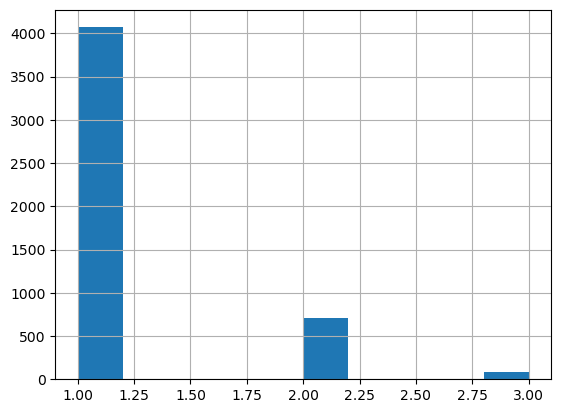

In [26]:
happiness.groupby('public_client_id').public_client_id.size().hist()

<Axes: >

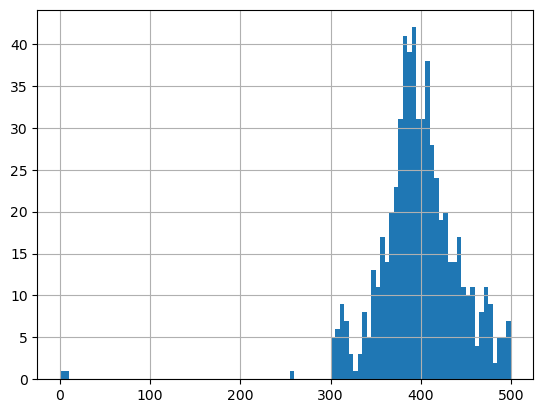

In [27]:
happiness.groupby('public_client_id')['days_in_program'].diff().hist(bins=100, range=[0,500])

In [28]:
happiness_to_merge = happiness[['public_client_id', 'days_in_program', 'vendor', 'happiness_total_score'] + happiness_features + happiness_features_numeric]
happiness_to_merge.rename(columns={'vendor': 'happiness_vendor', 'happiness_total_score': 'satisfaction_composite_avg'}, inplace=True)
happiness_to_merge['happiness_dip'] = happiness_to_merge.days_in_program
happiness_to_merge = happiness_to_merge.dropna(subset=['days_in_program', 'public_client_id'])

In [29]:
happiness_to_merge.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5741 entries, 0 to 5913
Data columns (total 63 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   public_client_id                                 5741 non-null   object 
 1   days_in_program                                  5741 non-null   float64
 2   happiness_vendor                                 5741 non-null   object 
 3   satisfaction_composite_avg                       5741 non-null   float64
 4   satisfaction                                     5741 non-null   object 
 5   satisfaction_cheerful_effect                     5741 non-null   object 
 6   satisfaction_dislike_way_i_am                    5741 non-null   object 
 7   satisfaction_find_beauty                         5741 non-null   object 
 8   satisfaction_find_time                           5741 non-null   object 
 9   satisfaction_fun_with_people       

In [28]:
happiness_to_merge.to_csv('happiness_df_11-13-2025.csv', index=False)

In [3]:
happiness_to_merge = pd.read_csv('happiness_df_11-13-2025.csv', dtype={'public_client_id': object})

In [30]:
happiness_to_merge

,public_client_id,days_in_program,happiness_vendor,satisfaction_composite_avg,satisfaction,satisfaction_cheerful_effect,satisfaction_dislike_way_i_am,satisfaction_find_beauty,satisfaction_find_time,satisfaction_fun_with_people,...,satisfaction_not_healthy_numeric,satisfaction_not_in_control_numeric,satisfaction_not_optimistic_numeric,satisfaction_purpose_numeric,satisfaction_rarely_rested_numeric,satisfaction_take_on_anything_numeric,satisfaction_very_happy_numeric,satisfaction_well_satisfied_numeric,satisfaction_world_is_a_bad_place_numeric,happiness_dip
0,01000261,37.0,Health 123,3.413793,(3) Slightly Disagree,(2) Moderately Disagree,(5) Moderately Agree,(6) Strongly Agree,(1) Strongly Disagree,(2) Moderately Disagree,...,4,5,4,2,2,2,3,2,3,37.0
1,01000552,0.0,Assessments,3.758621,(6) Strongly Agree,(5) Moderately Agree,(5) Moderately Agree,(6) Strongly Agree,(3) Slightly Disagree,(2) Moderately Disagree,...,4,4,1,1,2,5,6,4,1,0.0
2,01001298,0.0,Assessments,4.034483,(6) Strongly Agree,(5) Moderately Agree,(5) Moderately Agree,(6) Strongly Agree,(6) Strongly Agree,(2) Moderately Disagree,...,5,6,6,2,6,2,1,1,5,0.0
3,01001467,0.0,Assessments,3.724138,(4) Slightly Agree,(5) Moderately Agree,(1) Strongly Disagree,(5) Moderately Agree,(5) Moderately Agree,(2) Moderately Disagree,...,2,1,1,1,2,5,6,6,2,0.0
4,01001548,4.0,Assessments,3.413793,(3) Slightly Disagree,(4) Slightly Agree,(5) Moderately Agree,(5) Moderately Agree,(1) Strongly Disagree,(1) Strongly Disagree,...,5,4,2,5,5,2,2,2,2,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5909,QIRL,903.0,Assessments,3.793103,(5) Moderately Agree,(5) Moderately Agree,(2) Moderately Disagree,(6) Strongly Agree,(4) Slightly Agree,(2) Moderately Disagree,...,3,2,2,3,3,5,4,4,4,903.0
5910,ZU273983,1.0,Assessments,4.068966,(4) Slightly Agree,(4) Slightly Agree,(6) Strongly Agree,(6) Strongly Agree,(2) Moderately Disagree,(1) Strongly Disagree,...,6,5,3,2,6,4,4,4,5,1.0
5911,ZU612255,0.0,Assessments,3.689655,(4) Slightly Agree,(4) Slightly Agree,(2) Moderately Disagree,(5) Moderately Agree,(5) Moderately Agree,(1) Strongly Disagree,...,4,1,1,1,2,5,3,3,2,0.0
5912,ZU621944,4.0,Assessments,4.172414,(5) Moderately Agree,(5) Moderately Agree,(5) Moderately Agree,(6) Strongly Agree,(5) Moderately Agree,(2) Moderately Disagree,...,6,1,1,1,5,5,3,3,3,4.0


In [31]:
# sort by days_in_program for the merge below
sleep_merged = sleep_merged.sort_values(by='days_in_program')
happiness_to_merge = happiness_to_merge.sort_values(by='days_in_program')

In [32]:
# Merge the happiness qs onto sleep merged
sleep_merged = pd.merge_asof(
    sleep_merged,
    happiness_to_merge[
        happiness_to_merge.public_client_id.isin(sleep_merged.public_client_id)
    ],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=50
)

In [33]:
sleep_merged.shape

(1591, 5957)

In [34]:
sleep_merged[happiness_features[2]].value_counts()

satisfaction_dislike_way_i_am
(2) Moderately Disagree    380
(4) Slightly Agree         356
(1) Strongly Disagree      277
(5) Moderately Agree       253
(3) Slightly Disagree      140
(6) Strongly Agree          93
Name: count, dtype: int64

### Look at how far happiness is from microbe dip

In [35]:
sleep_merged['microbe_happiness_dip_diff'] = sleep_merged.reference_microbe_dip - sleep_merged.happiness_dip

<Axes: >

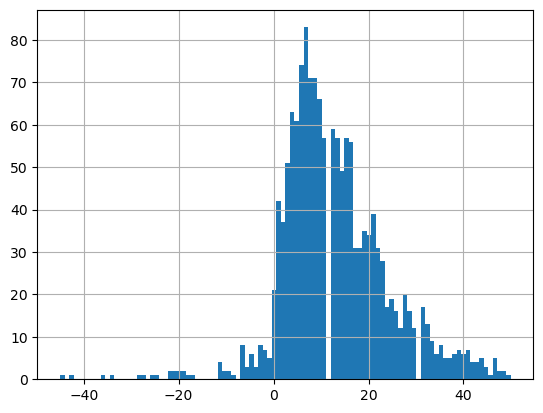

In [36]:
sleep_merged[happiness_features + ['microbe_happiness_dip_diff', 'happiness_dip']].dropna(subset=['happiness_dip']).microbe_happiness_dip_diff.hist(bins=100)

In [37]:
sleep_merged[happiness_features_numeric].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1591 entries, 0 to 1590
Data columns (total 29 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   satisfaction_numeric                             1499 non-null   float64
 1   satisfaction_cheerful_effect_numeric             1499 non-null   float64
 2   satisfaction_dislike_way_i_am_numeric            1499 non-null   float64
 3   satisfaction_find_beauty_numeric                 1499 non-null   float64
 4   satisfaction_find_time_numeric                   1499 non-null   float64
 5   satisfaction_fun_with_people_numeric             1499 non-null   float64
 6   satisfaction_gap_numeric                         1499 non-null   float64
 7   satisfaction_good_influence_numeric              1499 non-null   float64
 8   satisfaction_have_energy_numeric                 1499 non-null   float64
 9   satisfaction_intense_interest_

#### Update features_dict with dip and vendor

In [38]:
sleep_merged.filter(like='dip').columns

Index(['fitbit_dip', 'reference_microbe_dip', 'reference_fitbit_dip',
       'fitbit_dip_std', 'weights_dip',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium_binarized',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium',
       'metabolite_dip', 'diet_dip', 'microbe_diet_dip_diff',
       'mental_health_gut_sleep_q_dip', 'digestion_dip', 'supp_meds_dip',
       'adiponectin_serum', 'clinical_dip', 'microbe_clinical_dip_diff',
       'proteomics_dip', 'adiponectin_serum_log1p', 'stress_dip',
       'happiness_dip', 'microbe_happiness_dip_diff'],
      dtype='object')

In [39]:
features_dict['dip_features'].append('happiness_dip')

In [40]:
# check that it worked:
features_dict['dip_features']

['reference_microbe_dip',
 'weights_dip',
 'fitbit_dip',
 'metabolite_dip',
 'diet_dip',
 'mental_health_gut_sleep_q_dip',
 'digestion_dip',
 'supp_meds_dip',
 'clinical_dip',
 'proteomics_dip',
 'happiness_dip',
 'happiness_dip']

In [41]:
sleep_merged.happiness_vendor.value_counts()

happiness_vendor
Assessments    1220
Health 123      279
Name: count, dtype: int64

In [42]:
features_dict['vendor_features'].append('happiness_vendor')

In [43]:
# check that it worked:
features_dict['vendor_features']

['microbiome_vendor',
 'diet_vendor',
 'mental_health_gut_sleep_q_vendor',
 'digestion_vendor',
 'supp_meds_vendor',
 'clinical_vendor',
 'happiness_vendor',
 'happiness_vendor']

In [44]:
features_dict['happiness_features'] = happiness_features
features_dict['happiness_features_numeric'] = happiness_features_numeric

In [45]:
features_dict['happiness_features']

['satisfaction',
 'satisfaction_cheerful_effect',
 'satisfaction_dislike_way_i_am',
 'satisfaction_find_beauty',
 'satisfaction_find_time',
 'satisfaction_fun_with_people',
 'satisfaction_gap',
 'satisfaction_good_influence',
 'satisfaction_have_energy',
 'satisfaction_intense_interest_in_others',
 'satisfaction_involved',
 'satisfaction_joy_and_elation',
 'satisfaction_laugh_a_lot',
 'satisfaction_life_is_good',
 'satisfaction_life_is_rewarding',
 'satisfaction_make_decisions',
 'satisfaction_mentally_alert',
 'satisfaction_most_things_amusing',
 'satisfaction_no_happy_memories',
 'satisfaction_not_attractive',
 'satisfaction_not_healthy',
 'satisfaction_not_in_control',
 'satisfaction_not_optimistic',
 'satisfaction_purpose',
 'satisfaction_rarely_rested',
 'satisfaction_take_on_anything',
 'satisfaction_very_happy',
 'satisfaction_well_satisfied',
 'satisfaction_world_is_a_bad_place']

In [46]:
features_dict['happiness_features_numeric']

['satisfaction_numeric',
 'satisfaction_cheerful_effect_numeric',
 'satisfaction_dislike_way_i_am_numeric',
 'satisfaction_find_beauty_numeric',
 'satisfaction_find_time_numeric',
 'satisfaction_fun_with_people_numeric',
 'satisfaction_gap_numeric',
 'satisfaction_good_influence_numeric',
 'satisfaction_have_energy_numeric',
 'satisfaction_intense_interest_in_others_numeric',
 'satisfaction_involved_numeric',
 'satisfaction_joy_and_elation_numeric',
 'satisfaction_laugh_a_lot_numeric',
 'satisfaction_life_is_good_numeric',
 'satisfaction_life_is_rewarding_numeric',
 'satisfaction_make_decisions_numeric',
 'satisfaction_mentally_alert_numeric',
 'satisfaction_most_things_amusing_numeric',
 'satisfaction_no_happy_memories_numeric',
 'satisfaction_not_attractive_numeric',
 'satisfaction_not_healthy_numeric',
 'satisfaction_not_in_control_numeric',
 'satisfaction_not_optimistic_numeric',
 'satisfaction_purpose_numeric',
 'satisfaction_rarely_rested_numeric',
 'satisfaction_take_on_anything

In [57]:
with open('../features_dict.json', 'w') as f:
    json.dump(features_dict, f, indent=4)

# Merge on activity questionnaire

In [47]:
features_dict['vendor_features']

['microbiome_vendor',
 'diet_vendor',
 'mental_health_gut_sleep_q_vendor',
 'digestion_vendor',
 'supp_meds_vendor',
 'clinical_vendor',
 'happiness_vendor',
 'happiness_vendor']

In [48]:
df = get_snapshot('assessments_lifestyle')

activity_q = df.filter(regex='(?=.*moderate|vigorous)(?=.*duration)').columns.tolist()

df = df[["public_client_id", "days_in_program", "vendor"] + activity_q]
activity_q_renamed = ['moderate_activity_duration', 'vigorous_activity_duration']
df.rename(columns=dict(zip(activity_q, activity_q_renamed)), inplace=True)
df.rename(columns={"vendor": "sleep_q_vendor"}, inplace=True)
df['sleep_q_dip'] = df.days_in_program
df = df.dropna(subset=["public_client_id", "sleep_q_dip", "sleep_q_vendor"])
df = df.sort_values(by='sleep_q_dip')

In [49]:
df.dropna(subset='moderate_activity_duration').sleep_q_vendor.value_counts()

sleep_q_vendor
Assessments    5948
Health 123      762
Name: count, dtype: int64

In [50]:
df.sleep_q_vendor.value_counts()

sleep_q_vendor
Assessments      6399
Health 123        762
Self Reported     226
Name: count, dtype: int64

In [51]:
activity_q

['assessment:lifestyle:moderate_activity_duration:enum',
 'assessment:lifestyle:vigorous_activity_duration:enum']

In [52]:
df[activity_q_renamed[1]].value_counts()

vigorous_activity_duration
(0) N/A                 1379
(3) 30 min              1346
(4) 45 min              1156
(5) 60 min              1129
(2) 20 min               666
(6) More than 60 min     532
(1) 10 min               498
Name: count, dtype: int64

In [53]:
sleep_merged = pd.merge_asof(
    sleep_merged,
    df,
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

In [54]:
sleep_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1591 entries, 0 to 1590
Columns: 5962 entries, public_client_id to sleep_q_dip
dtypes: bool(1), float64(5243), int64(600), object(118)
memory usage: 72.4+ MB


In [55]:
sleep_merged.public_client_id.value_counts()

public_client_id
01315794    1
01602518    1
01826852    1
01788725    1
01360278    1
           ..
01274423    1
01611286    1
01320932    1
01652307    1
01887050    1
Name: count, Length: 1591, dtype: int64

In [56]:
features_dict.keys()

dict_keys(['heartrate_features', 'activity_features', 'sleep_features', 'covariate_features', 'sleep_features_log1p', 'sleep_features_log1p_resids', 'activity_features_resids', 'heartrate_features_resids', 'vendor_features', 'new_microbe_binarized_features', 'new_microbe_features_binary_10_90', 'new_microbe_features', 'diversity_features', 'dip_features', 'metabolite_features', 'food_freq_features', 'food_freq_features_daily', 'food_freq_from_non_freq_features', 'food_freq_from_non_freq_features_daily', 'diet_daily_features', 'gut_q_features', 'mental_health_q_features', 'sleep_disorder_q_features', 'digestion_features', 'supplement_features', 'med_features', 'clinical_features', 'proteomics_features', 'micom_features', 'metabolite_features_log', 'clinical_features_log1p', 'micom_features_log', 'happiness_features', 'happiness_features_numeric'])

# Merge on sleep questionnaires

In [57]:
df1 = get_snapshot('assessments_lifestyle')
# get the sleep related questions for this snapshot
sleep_q = df1.filter(regex='sleep').columns.tolist() + df1.filter(regex='wak').columns.tolist()
df1 = df1[["public_client_id", "days_in_program", "vendor"] + sleep_q]
sleep_q_renamed = ['avg_sleep', 'restful_sleep', 'sleep_concentration']
df1.rename(columns=dict(zip(sleep_q, sleep_q_renamed)), inplace=True)
df1.rename(columns={"vendor": "sleep_q_vendor"}, inplace=True)
df1['sleep_q_dip'] = df1.days_in_program
df1 = df1.dropna(subset=["public_client_id", "sleep_q_dip", "sleep_q_vendor"])
df1 = df1.sort_values(by='sleep_q_dip')

In [58]:
sleep_merged = pd.merge_asof(
    sleep_merged,
    df1,
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

In [59]:
# sleep questionnaire df
df2 = get_snapshot('assessments_health_history_misc')

# get the sleep related questions and also this snapshot has waking related question
sleep_q_2 = df2.filter(regex='sleep').columns.tolist() + df2.filter(regex='wak').columns.tolist()

df2 = df2[["public_client_id", "days_in_program", "vendor"] + sleep_q_2]
sleep_q_2_renamed = ['sleep_hours', 'sleep_trouble']
df2.rename(columns=dict(zip(sleep_q_2, sleep_q_2_renamed)), inplace=True)
df2.rename(columns={"vendor": "sleep_q_vendor"}, inplace=True)
df2['sleep_q_dip'] = df2.days_in_program
df2 = df2.dropna(subset=["public_client_id", "sleep_q_dip", "sleep_q_vendor"])
df2 = df2.sort_values(by='sleep_q_dip')

In [60]:
df2.sleep_hours.describe()

count            4926
unique              8
top       (5) 7 hours
freq             2228
Name: sleep_hours, dtype: object

In [61]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9729 entries, 674 to 551
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   public_client_id                        9729 non-null   object 
 1   days_in_program                         9729 non-null   float64
 2   sleep_q_vendor                          9729 non-null   object 
 3   sleep_hours                             4926 non-null   object 
 4   sleep_trouble                           4926 non-null   object 
 5   assessment:lifestyle:night_waking:real  4926 non-null   float64
 6   sleep_q_dip                             9729 non-null   float64
dtypes: float64(3), object(4)
memory usage: 608.1+ KB


In [62]:
df2.sleep_trouble.value_counts()

sleep_trouble
(0) Never or less than once a month    1461
(1) Less than one night per week       1390
(2) 1-2 nights per week                1140
(4) 3 nights or more per week           935
Name: count, dtype: int64

In [63]:
sleep_merged = pd.merge_asof(
    sleep_merged,
    df2[['public_client_id', 'days_in_program', 'sleep_hours', 'sleep_trouble']],
    by="public_client_id",
    on="days_in_program",
    direction="nearest",
    tolerance=100
)

In [64]:
sleep_merged.restful_sleep.value_counts(normalize=True)

restful_sleep
(0) Yes       0.404545
(1) No        0.395455
(2) Unsure    0.200000
Name: proportion, dtype: float64

#### Switch restful sleep so that unsure is in the middle and no is the right-most response

In [140]:
sleep_merged["restful_sleep"] = sleep_merged["restful_sleep"].replace({
    "(0) Yes": "(2) Yes",
    "(1) No": "(0) No",
    "(2) Unsure": "(1) Unsure"
})

In [142]:
sleep_merged.restful_sleep.value_counts()

restful_sleep
(0) Yes       534
(2) No        522
(1) Unsure    264
Name: count, dtype: int64

In [67]:
sleep_merged.sleep_trouble.value_counts()

sleep_trouble
(2) 1-2 nights per week                53
(0) Never or less than once a month    44
(1) Less than one night per week       43
(4) 3 nights or more per week          37
Name: count, dtype: int64

In [68]:
sleep_merged.sleep_concentration.value_counts()

sleep_concentration
(1) A little             94
(2) A moderate amount    63
(0) Not at all           30
(4) A lot                14
(5) An extreme amount     1
Name: count, dtype: int64

In [69]:
sleep_merged.avg_sleep.value_counts()

avg_sleep
(2) 7 to 9 hours         903
(1) Less than 6 hours    411
(3) More than 9 hours      6
Name: count, dtype: int64

# Happiness Questionnaire Items ~ Fitbit sleep + sex + age + BMI + PC1 + PC2 + PC3

In [70]:
sleep_merged['happiness_dip_minus_fitbit_dip'] = sleep_merged.happiness_dip - sleep_merged.fitbit_dip

In [71]:
formula = "{dependent_feature} ~ {independent_feature} + age + BMI_CALC + PC1 + PC2 + PC3 + C(sex) + C(happiness_vendor) + happiness_dip_minus_fitbit_dip"

In [72]:
drop_columns = ['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'happiness_vendor', 'happiness_dip_minus_fitbit_dip']

tests, error_log = linear_regression_results(independent_features=features_dict['sleep_features_log1p_resids'], dependent_features=features_dict['happiness_features_numeric'], drop_subset_list=drop_columns, 
                              formula_string=formula, df=sleep_merged, test_df=sleep_merged, metabolite_anns=False, categorical=False,
                              categorical_poly=False, n_per_predictor=10,
                              model_type='linear', train_test=False, auto_cognate=False)

from statsmodels.stats.multitest import multipletests
# Apply FDR correction
tests = tests.groupby('dependent_feature').apply(
    lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
).reset_index(drop=True)

tests.to_csv('fitbit_sleep_to_happiness_results_02-27-2026.csv', index=False)

This is microbe regression


In [60]:
# All possible regressions were fit!
error_log

""


In [73]:
tests[tests.q < 0.1]

,dependent_feature,independent_feature,beta,t_statistic,p,n_train,n_test,r2_train,r2_test,formula,q
30,satisfaction_dislike_way_i_am_numeric,sleep_minutesAsleep_std_log1p_resid,0.523785,4.225388,0.000026,936.0,936,0.148370,NaN,satisfaction_dislike_way_i_am_numeric ~ sleep_...,0.000472
33,satisfaction_dislike_way_i_am_numeric,sleep_timeInBed_std_log1p_resid,0.705622,4.050590,0.000059,521.0,521,0.139191,NaN,satisfaction_dislike_way_i_am_numeric ~ sleep_...,0.000531
97,satisfaction_gap_numeric,sleep_timeInBed_log1p_resid,-1.633439,-2.694207,0.007288,521.0,521,0.041879,NaN,satisfaction_gap_numeric ~ sleep_timeInBed_log...,0.058101
105,satisfaction_gap_numeric,sleep_timeInBed_std_log1p_resid,0.443023,2.596702,0.009683,521.0,521,0.040924,NaN,satisfaction_gap_numeric ~ sleep_timeInBed_std...,0.058101
106,satisfaction_gap_numeric,bedtime_int_log1p_resid,3.009915,3.355694,0.000812,1499.0,1499,0.041598,NaN,satisfaction_gap_numeric ~ bedtime_int_log1p_r...,0.014609
131,satisfaction_have_energy_numeric,sleep_minutesAwake_log1p_resid,-0.258576,-2.139389,0.032877,521.0,521,0.083380,NaN,satisfaction_have_energy_numeric ~ sleep_minut...,0.084542
134,satisfaction_have_energy_numeric,sleep_awakeDuration_std_log1p_resid,-0.358122,-2.901048,0.003807,936.0,936,0.105081,NaN,satisfaction_have_energy_numeric ~ sleep_awake...,0.013706
135,satisfaction_have_energy_numeric,sleep_awakeningsCount_std_log1p_resid,-0.429812,-2.796751,0.005228,1499.0,1499,0.104199,NaN,satisfaction_have_energy_numeric ~ sleep_awake...,0.015685
136,satisfaction_have_energy_numeric,sleep_efficiency_std_log1p_resid,-0.332805,-3.105265,0.001937,1499.0,1499,0.105287,NaN,satisfaction_have_energy_numeric ~ sleep_effic...,0.011093
138,satisfaction_have_energy_numeric,sleep_minutesAsleep_std_log1p_resid,-0.374573,-3.035930,0.002465,936.0,936,0.105848,NaN,satisfaction_have_energy_numeric ~ sleep_minut...,0.011093


# Fitbit activity ~ activity_q + sex + age + BMI + PC1-3

In [78]:
sleep_merged.filter(like='dip').columns

Index(['fitbit_dip', 'reference_microbe_dip', 'reference_fitbit_dip',
       'fitbit_dip_std', 'weights_dip',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium_binarized',
       'Bacteria_Actinobacteria_Actinobacteria_Propionibacteriales_Propionibacteriaceae_Acidipropionibacterium',
       'metabolite_dip', 'diet_dip', 'microbe_diet_dip_diff',
       'mental_health_gut_sleep_q_dip', 'digestion_dip', 'supp_meds_dip',
       'adiponectin_serum', 'clinical_dip', 'microbe_clinical_dip_diff',
       'proteomics_dip', 'adiponectin_serum_log1p', 'stress_dip',
       'happiness_dip', 'microbe_happiness_dip_diff', 'sleep_q_dip_x',
       'sleep_q_dip_y', 'happiness_dip_minus_fitbit_dip'],
      dtype='object')

In [82]:
# Ok the sleep_q_dip and sleep_vendor from both sleep questionnaire snapshots are the same
(sleep_merged.sleep_q_dip_x == sleep_merged.sleep_q_dip_y).sum()

1591

In [89]:
(sleep_merged.sleep_q_vendor_x == sleep_merged.sleep_q_vendor_y).sum()

1591

In [83]:
sleep_merged['fitbit_dip_minus_sleep_q_dip'] = sleep_merged.fitbit_dip - sleep_merged.sleep_q_dip_x

In [91]:
formula = "{dependent_feature} ~ C({independent_feature}, Poly) + C(sex) + age + BMI_CALC + PC1 + PC2 + PC3 + C(sleep_q_vendor_x) + fitbit_dip_minus_sleep_q_dip"

In [85]:
activity_q_renamed

['moderate_activity_duration', 'vigorous_activity_duration']

In [92]:
sleep_merged.dropna(subset='vigorous_activity_duration').sleep_q_vendor_x.value_counts(normalize=True)

sleep_q_vendor_x
Assessments    0.803289
Health 123     0.196711
Name: proportion, dtype: float64

In [94]:
drop_columns = ['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'sleep_q_vendor_x', 'fitbit_dip_minus_sleep_q_dip']

tests, error_log = linear_regression_results(dependent_features=["activities_activityCalories_resid", "activities_steps_resid", "activities_floors_resid"], independent_features=activity_q_renamed, drop_subset_list=drop_columns, 
                              formula_string=formula, df=sleep_merged, test_df=sleep_merged, metabolite_anns=False, categorical=False,
                              categorical_poly=True, n_per_predictor=10,
                              model_type='linear', train_test=False, auto_cognate=False, check_iv_levels=False)

from statsmodels.stats.multitest import multipletests
tests = tests.groupby('dependent_feature').apply(
    lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
).reset_index(drop=True)

tests.to_csv('happiness_activity_sleep_mental-illness_sleep-disorder_regressions_02-27-2026/activity_q_to_fitbit_activity_results_02-27-2026.csv', index=False)

This is microbe regression


In [112]:
tests[tests.q < 0.1]

,dependent_feature,independent_feature,beta,t_statistic,p,n_train,n_test,r2_train,r2_test,formula,q
0,activities_activityCalories_resid,moderate_activity_duration,204.170525,5.648319,1.933896e-08,1521.0,1521,0.339210,NaN,activities_activityCalories_resid ~ C(moderate...,1.933896e-08
1,activities_activityCalories_resid,vigorous_activity_duration,165.631452,5.998421,2.491126e-09,1520.0,1520,0.345756,NaN,activities_activityCalories_resid ~ C(vigorous...,4.982252e-09
2,activities_floors_resid,moderate_activity_duration,4.269041,3.437688,6.026837e-04,1521.0,1521,0.143018,NaN,activities_floors_resid ~ C(moderate_activity_...,6.026837e-04
3,activities_floors_resid,vigorous_activity_duration,5.627811,5.954293,3.245254e-09,1520.0,1520,0.158494,NaN,activities_floors_resid ~ C(vigorous_activity_...,6.490508e-09
4,activities_steps_resid,moderate_activity_duration,1624.402202,5.567388,3.057023e-08,1521.0,1521,0.154216,NaN,activities_steps_resid ~ C(moderate_activity_d...,3.057023e-08
5,activities_steps_resid,vigorous_activity_duration,1626.155682,7.356902,3.080987e-13,1520.0,1520,0.176468,NaN,activities_steps_resid ~ C(vigorous_activity_d...,6.161975e-13


# Fitbit sleep ~ sleep_q_features + sex + age + BMI + PC1-3

In [143]:
sleep_merged['fitbit_dip_minus_sleep_q_dip'] = sleep_merged.fitbit_dip - sleep_merged.sleep_q_dip_x

In [144]:
formula = "{dependent_feature} ~ C({independent_feature}, Poly) + C(sex) + age + BMI_CALC + PC1 + PC2 + PC3 + C(sleep_q_vendor_x) + fitbit_dip_minus_sleep_q_dip"

In [149]:
# Full set of sleep questions
sleep_q_renamed = sleep_q_renamed + sleep_q_2_renamed

In [152]:
sleep_q_renamed

['avg_sleep',
 'restful_sleep',
 'sleep_concentration',
 'sleep_hours',
 'sleep_trouble']

In [154]:
drop_columns = ['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'sleep_q_vendor_x', 'fitbit_dip_minus_sleep_q_dip']

tests, error_log = linear_regression_results(dependent_features=features_dict['sleep_features_log1p_resids'], independent_features=sleep_q_renamed, drop_subset_list=drop_columns, 
                              formula_string=formula, df=sleep_merged, test_df=sleep_merged, metabolite_anns=False, categorical=False,
                              categorical_poly=True, n_per_predictor=10,
                              model_type='linear', train_test=False, auto_cognate=False, check_iv_levels=False)

from statsmodels.stats.multitest import multipletests
# Apply FDR correction
tests = tests.groupby('dependent_feature').apply(
    lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
).reset_index(drop=True)

tests.to_csv('happiness_activity_sleep_mental-illness_sleep-disorder_regressions_02-27-2026/sleep_q_to_fitbit_sleep_results_02-27-2026.csv', index=False)

This is microbe regression


In [156]:
tests[tests.q < 0.1]

,dependent_feature,independent_feature,beta,t_statistic,p,n_train,n_test,r2_train,r2_test,formula,q
11,sleep_awakeDuration_log1p_resid,restful_sleep,0.057050,2.425657,0.015477,909.0,909,0.077084,NaN,sleep_awakeDuration_log1p_resid ~ C(restful_sl...,0.030954
13,sleep_awakeDuration_std_log1p_resid,restful_sleep,0.058040,2.913433,0.003663,909.0,909,0.058562,NaN,sleep_awakeDuration_std_log1p_resid ~ C(restfu...,0.007327
25,sleep_efficiency_log1p_resid,restful_sleep,-0.009377,-2.653640,0.008059,1320.0,1320,0.010924,NaN,sleep_efficiency_log1p_resid ~ C(restful_sleep...,0.040296
30,sleep_efficiency_std_log1p_resid,restful_sleep,0.048477,3.199112,0.001412,1320.0,1320,0.011107,NaN,sleep_efficiency_std_log1p_resid ~ C(restful_s...,0.003529
31,sleep_efficiency_std_log1p_resid,sleep_concentration,0.956172,4.949749,0.000002,202.0,202,0.180903,NaN,sleep_efficiency_std_log1p_resid ~ C(sleep_con...,0.000008
36,sleep_minutesAfterWakeup_log1p_resid,sleep_concentration,1.048269,2.985686,0.003202,202.0,202,0.086582,NaN,sleep_minutesAfterWakeup_log1p_resid ~ C(sleep...,0.016009
44,sleep_minutesAsleep_log1p_resid,avg_sleep,0.120047,3.131371,0.001796,909.0,909,0.161221,NaN,"sleep_minutesAsleep_log1p_resid ~ C(avg_sleep,...",0.001901
45,sleep_minutesAsleep_log1p_resid,restful_sleep,-0.023203,-3.114466,0.001901,909.0,909,0.052719,NaN,sleep_minutesAsleep_log1p_resid ~ C(restful_sl...,0.001901
47,sleep_minutesAsleep_std_log1p_resid,restful_sleep,0.071847,3.592625,0.000345,909.0,909,0.033857,NaN,sleep_minutesAsleep_std_log1p_resid ~ C(restfu...,0.000690
49,sleep_minutesAwake_log1p_resid,restful_sleep,0.095212,2.549332,0.011081,527.0,527,0.028683,NaN,sleep_minutesAwake_log1p_resid ~ C(restful_sle...,0.022162


# Mental Illness / Sleep Disorder ~ fitbit sleep + sex + age + BMI + PC1-3 regressions

In [102]:
features_dict['mental_health_q_features']

['mental_health_alcohol_abuse_self_anytime_before',
 'mental_health_binge_eating_disorder_self_anytime_before',
 'mental_health_anorexia_self_anytime_before',
 'mental_health_drug_abuse_self_anytime_before',
 'mental_health_adhd_add_self_anytime_before',
 'mental_health_anxiety_disorder_self_anytime_before',
 'mental_health_other_self_anytime_before',
 'mental_health_schizophrenia_self_anytime_before',
 'mental_health_bulimia_self_anytime_before',
 'mental_health_sad_self_anytime_before',
 'mental_health_other_eating_disorder_self_anytime_before',
 'mental_health_depression_self_anytime_before',
 'mental_health_obsessive_compulsive_disorder_self_anytime_before',
 'mental_health_bipolar_disorder_self_anytime_before']

In [124]:
sleep_merged['mental_health_gut_sleep_q_dip_minus_fitbit_dip'] = sleep_merged.mental_health_gut_sleep_q_dip - sleep_merged.fitbit_dip

In [125]:
formula = "{dependent_feature} ~ {independent_feature} + C(sex) + age + BMI_CALC + PC1 + PC2 + PC3 + mental_health_gut_sleep_q_vendor + mental_health_gut_sleep_q_dip_minus_fitbit_dip"

In [126]:
drop_columns = ['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'mental_health_gut_sleep_q_vendor', 'mental_health_gut_sleep_q_dip_minus_fitbit_dip']

tests, error_log = linear_regression_results(independent_features=features_dict['sleep_features_log1p_resids'], dependent_features=features_dict['mental_health_q_features'], drop_subset_list=drop_columns, 
                              formula_string=formula, df=sleep_merged, test_df=sleep_merged, metabolite_anns=False, categorical=False,
                              categorical_poly=False, n_per_predictor=10,
                              model_type='logistic', train_test=False, auto_cognate=False)

from statsmodels.stats.multitest import multipletests
# Apply FDR correction
tests = tests.groupby('dependent_feature').apply(
    lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
).reset_index(drop=True)

tests.to_csv('happiness_activity_sleep_mental-illness_sleep-disorder_regressions_02-27-2026/fitbit_sleep_to_mental_illness_q_results_02-27-2026.csv', index=False)

This is microbe regression


In [127]:
error_log

,dependent_feature,independent_feature,formula,error,model_type
0,mental_health_alcohol_abuse_self_anytime_before,sleep_awakeningsCount_log1p_resid,mental_health_alcohol_abuse_self_anytime_befor...,1s in DEPENDENT variable make up only 4.11% of...,logistic
1,mental_health_alcohol_abuse_self_anytime_before,sleep_efficiency_log1p_resid,mental_health_alcohol_abuse_self_anytime_befor...,1s in DEPENDENT variable make up only 4.11% of...,logistic
2,mental_health_alcohol_abuse_self_anytime_before,sleep_minutesAfterWakeup_log1p_resid,mental_health_alcohol_abuse_self_anytime_befor...,1s in DEPENDENT variable make up only 4.11% of...,logistic
3,mental_health_alcohol_abuse_self_anytime_before,sleep_minutesAwake_log1p_resid,mental_health_alcohol_abuse_self_anytime_befor...,Independent variable has only one unique value,logistic
4,mental_health_alcohol_abuse_self_anytime_before,sleep_timeInBed_log1p_resid,mental_health_alcohol_abuse_self_anytime_befor...,Independent variable has only one unique value,logistic
...,...,...,...,...,...
189,mental_health_bipolar_disorder_self_anytime_be...,sleep_minutesAwake_std_log1p_resid,mental_health_bipolar_disorder_self_anytime_be...,1s in DEPENDENT variable make up only 1.10% of...,logistic
190,mental_health_bipolar_disorder_self_anytime_be...,sleep_restlessDuration_std_log1p_resid,mental_health_bipolar_disorder_self_anytime_be...,1s in DEPENDENT variable make up only 1.12% of...,logistic
191,mental_health_bipolar_disorder_self_anytime_be...,sleep_timeInBed_std_log1p_resid,mental_health_bipolar_disorder_self_anytime_be...,1s in DEPENDENT variable make up only 1.10% of...,logistic
192,mental_health_bipolar_disorder_self_anytime_be...,bedtime_int_log1p_resid,mental_health_bipolar_disorder_self_anytime_be...,1s in DEPENDENT variable make up only 0.94% of...,logistic


In [128]:
tests.sort_values(by='q')

,dependent_feature,independent_feature,beta,t_statistic,p,n_train,n_test,r2_train,r2_test,formula,q
28,mental_health_depression_self_anytime_before,sleep_minutesAsleep_std_log1p_resid,0.496579,2.422310,0.015422,964,964,0.050203,NaN,mental_health_depression_self_anytime_before ~...,0.277599
32,mental_health_depression_self_anytime_before,bedtime_int_log1p_resid,3.321965,2.154247,0.031221,1575,1575,0.046904,NaN,mental_health_depression_self_anytime_before ~...,0.280987
33,mental_health_depression_self_anytime_before,bedtime_int_std_log1p_resid,0.678075,1.804473,0.071157,1575,1575,0.046074,NaN,mental_health_depression_self_anytime_before ~...,0.426943
11,mental_health_anxiety_disorder_self_anytime_be...,sleep_awakeningsCount_std_log1p_resid,1.048919,1.145119,0.252160,219,219,0.133694,NaN,mental_health_anxiety_disorder_self_anytime_be...,0.537583
8,mental_health_anxiety_disorder_self_anytime_be...,sleep_awakeningsCount_log1p_resid,0.815501,0.971560,0.331269,219,219,0.131856,NaN,mental_health_anxiety_disorder_self_anytime_be...,0.537583
15,mental_health_anxiety_disorder_self_anytime_be...,bedtime_int_std_log1p_resid,1.721670,1.329269,0.183759,219,219,0.136004,NaN,mental_health_anxiety_disorder_self_anytime_be...,0.537583
9,mental_health_anxiety_disorder_self_anytime_be...,sleep_efficiency_log1p_resid,2.816706,0.962120,0.335989,219,219,0.133288,NaN,mental_health_anxiety_disorder_self_anytime_be...,0.537583
10,mental_health_anxiety_disorder_self_anytime_be...,sleep_minutesAfterWakeup_log1p_resid,-0.398972,-0.984317,0.324959,219,219,0.132506,NaN,mental_health_anxiety_disorder_self_anytime_be...,0.537583
14,mental_health_anxiety_disorder_self_anytime_be...,bedtime_int_log1p_resid,4.178913,0.763739,0.445023,219,219,0.130026,NaN,mental_health_anxiety_disorder_self_anytime_be...,0.593364
6,mental_health_adhd_add_self_anytime_before,bedtime_int_log1p_resid,12.343215,1.775684,0.075785,219,219,0.124442,NaN,mental_health_adhd_add_self_anytime_before ~ b...,0.606280


In [129]:
features_dict['sleep_disorder_q_features']

['sleep_condition_restless_leg_syndrome_self_anytime_before',
 'sleep_condition_other_self_anytime_before',
 'sleep_condition_narcolepsy_self_anytime_before',
 'sleep_condition_insomnia_self_anytime_before',
 'sleep_condition_apnea_self_anytime_before']

In [130]:
drop_columns = ['age', 'BMI_CALC', 'PC1', 'PC2', 'PC3', 'sex', 'mental_health_gut_sleep_q_vendor', 'mental_health_gut_sleep_q_dip_minus_fitbit_dip']

tests, error_log = linear_regression_results(independent_features=features_dict['sleep_features_log1p_resids'], dependent_features=features_dict['sleep_disorder_q_features'], drop_subset_list=drop_columns, 
                              formula_string=formula, df=sleep_merged, test_df=sleep_merged, metabolite_anns=False, categorical=False,
                              categorical_poly=False, n_per_predictor=10,
                              model_type='logistic', train_test=False, auto_cognate=False)

from statsmodels.stats.multitest import multipletests
# Apply FDR correction
tests = tests.groupby('dependent_feature').apply(
    lambda group: group.assign(q=multipletests(group['p'], method='fdr_bh')[1])
).reset_index(drop=True)

tests.to_csv('happiness_activity_sleep_mental-illness_sleep-disorder_regressions_02-27-2026/fitbit_sleep_to_sleep_disorder_q_results_02-27-2026.csv', index=False)

This is microbe regression


In [131]:
tests[tests.q < 0.1]

,dependent_feature,independent_feature,beta,t_statistic,p,n_train,n_test,r2_train,r2_test,formula,q
19,sleep_condition_insomnia_self_anytime_before,sleep_efficiency_log1p_resid,-3.532950,-2.393192,0.016702,219,219,0.046971,NaN,sleep_condition_insomnia_self_anytime_before ~...,0.043780
20,sleep_condition_insomnia_self_anytime_before,sleep_minutesAfterWakeup_log1p_resid,0.598539,2.215334,0.026737,219,219,0.042779,NaN,sleep_condition_insomnia_self_anytime_before ~...,0.043780
22,sleep_condition_insomnia_self_anytime_before,sleep_efficiency_std_log1p_resid,1.422701,2.807342,0.004995,219,219,0.057047,NaN,sleep_condition_insomnia_self_anytime_before ~...,0.039962
23,sleep_condition_insomnia_self_anytime_before,sleep_minutesAfterWakeup_std_log1p_resid,0.657027,2.408189,0.016032,219,219,0.047222,NaN,sleep_condition_insomnia_self_anytime_before ~...,0.043780
24,sleep_condition_insomnia_self_anytime_before,bedtime_int_log1p_resid,10.222842,2.206309,0.027362,219,219,0.044396,NaN,sleep_condition_insomnia_self_anytime_before ~...,0.043780


# Opening and visualizing the results

Use the codeblock below to convert the tests df as if we were opening adjusted and unadjusted dfs, this is so the df can be used in the visualization function

In [157]:
# Toggle the code blocks below by either opening the activity_q feature set or not

feature_sets = [
    'sleep_q',
    #'activity_q',
    'sleep_disorder_q',
    'mental_illness_q',
    'happiness'
]

In [158]:
# Opening regression results for 08/25/2025 with the additional season and weekend-weekday ratio covariates
import pandas as pd
import numpy as np
import os

combined_with_feature_set = []

for feature_set in feature_sets:

    df1 = pd.read_csv(next(os.path.join("happiness_activity_sleep_mental-illness_sleep-disorder_regressions_02-27-2026", f)
                       for f in os.listdir("happiness_activity_sleep_mental-illness_sleep-disorder_regressions_02-27-2026")
                       if feature_set in f))
    df2 = df1.copy()
    
    # Compute beta sign for merging purposes
    df1['beta_sign'] = np.sign(df1['beta'])
    df2['beta_sign'] = np.sign(df2['beta'])
    
    # Rename columns to distinguish adjusted/unadjusted
    df1.rename(columns={
        # Keep this or not
        'n_train': 'n_adjusted',
        ###
        'beta': 'beta_adjusted',
        't_statistic': 't_statistic_adjusted',
        'p': 'p_adjusted',
        'q': 'q_adjusted'
    }, inplace=True)
    
    df2.rename(columns={
        # Keep this or not
        'n_train': 'n_unadjusted',
        ###
        'beta': 'beta_unadjusted',
        't_statistic': 't_statistic_unadjusted',
        'p': 'p_unadjusted',
        'q': 'q_unadjusted'
    }, inplace=True)
    
    # Merge into wide format using outer join to preserve all hits
    merged = pd.merge(
        df1[['dependent_feature', 'independent_feature', 'beta_sign', 'beta_adjusted', 't_statistic_adjusted', 'p_adjusted', 'q_adjusted', 'n_adjusted']],
        df2[['dependent_feature', 'independent_feature', 'beta_sign', 'beta_unadjusted', 't_statistic_unadjusted', 'p_unadjusted', 'q_unadjusted', 'n_unadjusted']],
        on=['dependent_feature', 'independent_feature', 'beta_sign'],
        how='outer'
    )
    
    # Mark q < 0.1 significance, preserving NaNs
    merged['from_adjusted'] = merged['q_adjusted'].apply(
        lambda q: 1 if q < 0.1 else 0 if pd.notna(q) else np.nan
    )
    
    merged['from_unadjusted'] = merged['q_unadjusted'].apply(
        lambda q: 1 if q < 0.1 else 0 if pd.notna(q) else np.nan
    )
    
    # shared_hit = 1 only if both are 1 (not NaN)
    merged['shared_hit'] = ((merged['from_adjusted'] == 1) & (merged['from_unadjusted'] == 1)).astype(int)
    
    
    # Compute change in t-statistic magnitude and direction
    merged['t_delta'] = merged.apply(
        lambda row: abs(row['t_statistic_adjusted']) - abs(row['t_statistic_unadjusted'])
        if pd.notna(row['t_statistic_adjusted']) and pd.notna(row['t_statistic_unadjusted']) else np.nan,
        axis=1
    )
    merged['t_direction'] = merged['t_delta'].apply(
        lambda x: 'stronger' if x > 0 else 'weaker' if x < 0 else 'no_change' if pd.notna(x) else np.nan
    )
    
    merged['feature_set'] = feature_set  # add omic set label

    if 'sleep_q' in feature_set:
        merged.rename(columns={'independent_feature':'dependent_feature', 'dependent_feature':'independent_feature'}, inplace=True)

    combined_with_feature_set.append(merged)

# Create the combined df that combines all the adjusted and unadjusted results for easier plotting
combined_df = pd.concat(combined_with_feature_set, ignore_index=True)

In [159]:
combined_df.independent_feature.unique()

array(['bedtime_int_log1p_resid', 'bedtime_int_std_log1p_resid',
       'sleep_awakeDuration_log1p_resid',
       'sleep_awakeDuration_std_log1p_resid',
       'sleep_awakeningsCount_log1p_resid',
       'sleep_awakeningsCount_std_log1p_resid',
       'sleep_efficiency_log1p_resid', 'sleep_efficiency_std_log1p_resid',
       'sleep_minutesAfterWakeup_log1p_resid',
       'sleep_minutesAfterWakeup_std_log1p_resid',
       'sleep_minutesAsleep_log1p_resid',
       'sleep_minutesAsleep_std_log1p_resid',
       'sleep_minutesAwake_log1p_resid',
       'sleep_minutesAwake_std_log1p_resid',
       'sleep_restlessDuration_log1p_resid',
       'sleep_restlessDuration_std_log1p_resid',
       'sleep_timeInBed_log1p_resid', 'sleep_timeInBed_std_log1p_resid'],
      dtype=object)

In [81]:
combined_df = combined_df[combined_df.independent_feature.str.contains('moderate_activity_duration|vigorous_activity_duration')]

In [160]:
combined_df

,independent_feature,dependent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,p_unadjusted,q_unadjusted,n_unadjusted,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set
0,bedtime_int_log1p_resid,avg_sleep,-1.0,-0.013667,-1.188924,0.234685,0.586713,1320.0,-0.013667,-1.188924,0.234685,0.586713,1320.0,0,0,0,0.0,no_change,sleep_q
1,bedtime_int_log1p_resid,restful_sleep,1.0,0.000676,0.391570,0.695439,0.695439,1320.0,0.000676,0.391570,0.695439,0.695439,1320.0,0,0,0,0.0,no_change,sleep_q
2,bedtime_int_log1p_resid,sleep_concentration,-1.0,-0.010870,-0.453428,0.650758,0.695439,202.0,-0.010870,-0.453428,0.650758,0.695439,202.0,0,0,0,0.0,no_change,sleep_q
3,bedtime_int_log1p_resid,sleep_hours,-1.0,-0.011637,-0.496848,0.619957,0.695439,177.0,-0.011637,-0.496848,0.619957,0.695439,177.0,0,0,0,0.0,no_change,sleep_q
4,bedtime_int_log1p_resid,sleep_trouble,1.0,0.008056,1.435477,0.153033,0.586713,177.0,0.008056,1.435477,0.153033,0.586713,177.0,0,0,0,0.0,no_change,sleep_q
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
637,sleep_minutesAwake_std_log1p_resid,satisfaction_world_is_a_bad_place_numeric,1.0,0.101236,0.853316,0.393884,0.708991,521.0,0.101236,0.853316,0.393884,0.708991,521.0,0,0,0,0.0,no_change,happiness
638,sleep_restlessDuration_std_log1p_resid,satisfaction_world_is_a_bad_place_numeric,1.0,0.144863,1.760613,0.078634,0.447581,936.0,0.144863,1.760613,0.078634,0.447581,936.0,0,0,0,0.0,no_change,happiness
639,sleep_timeInBed_std_log1p_resid,satisfaction_world_is_a_bad_place_numeric,-1.0,-0.073757,-0.477229,0.633403,0.873165,521.0,-0.073757,-0.477229,0.633403,0.873165,521.0,0,0,0,0.0,no_change,happiness
640,bedtime_int_log1p_resid,satisfaction_world_is_a_bad_place_numeric,1.0,1.693770,2.075195,0.038140,0.447581,1499.0,1.693770,2.075195,0.038140,0.447581,1499.0,0,0,0,0.0,no_change,happiness


In [15]:
combined_df.groupby('feature_set').n_adjusted.describe()

,count,mean,std,min,25%,50%,75%,max
feature_set,,,,,,,,
activity_q,6.0,1520.5,0.547723,1520.0,1520.0,1520.5,1521.0,1521.0


In [161]:
combined_df.groupby('feature_set').n_adjusted.describe()

,count,mean,std,min,25%,50%,75%,max
feature_set,,,,,,,,
happiness,522.0,1094.000000,393.038510,521.0,936.0,936.0,1499.0,1499.0
mental_illness_q,34.0,706.470588,560.170009,219.0,219.0,533.0,964.0,1575.0
sleep_disorder_q,26.0,866.615385,567.420625,219.0,219.0,980.0,1591.0,1591.0
sleep_q,60.0,678.200000,473.822995,177.0,177.0,527.0,1320.0,1320.0


In [162]:
combined_df.rename(columns={'dependent_feature':'independent_feature', 'independent_feature':'dependent_feature'}, inplace=True)

In [163]:
from scipy.stats import spearmanr

shared_hits_df = combined_df[combined_df.shared_hit == 1]

# Initialize list for results
correlation_results = []

covariate_features = ['age',
                      'BMI_CALC',
                      'PC1',
                      'PC2',
                      'PC3',
                      'sex']

# Iterate over each row to calculate correlation
for feature_set in shared_hits_df.feature_set.unique():    
    for _, row in shared_hits_df[shared_hits_df.feature_set.str.contains(feature_set)].iterrows():
        
        ind = row['independent_feature']
        dep = row['dependent_feature']
    
        # Drop NA rows before correlation
        sleep_data = sleep_merged.dropna(subset=[ind, dep] + covariate_features)
        
        corr, pval = spearmanr(sleep_data[ind], sleep_data[dep])
        
        correlation_results.append({
            'independent_feature': ind,
            'dependent_feature': dep,
            'correlation': corr
        })

# Convert to DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Merge correlation results into combined_df
final_df = shared_hits_df.merge(correlation_df, on=['independent_feature', 'dependent_feature'], how='left')

In [164]:
final_df.feature_set.value_counts()

feature_set
happiness           58
sleep_q             16
sleep_disorder_q     5
Name: count, dtype: int64

In [165]:
final_df

,dependent_feature,independent_feature,beta_sign,beta_adjusted,t_statistic_adjusted,p_adjusted,q_adjusted,n_adjusted,beta_unadjusted,t_statistic_unadjusted,p_unadjusted,q_unadjusted,n_unadjusted,from_adjusted,from_unadjusted,shared_hit,t_delta,t_direction,feature_set,correlation
0,sleep_awakeDuration_log1p_resid,restful_sleep,1.0,0.057050,2.425657,0.015477,0.030954,909.0,0.057050,2.425657,0.015477,0.030954,909.0,1,1,1,0.0,no_change,sleep_q,0.060157
1,sleep_awakeDuration_std_log1p_resid,restful_sleep,1.0,0.058040,2.913433,0.003663,0.007327,909.0,0.058040,2.913433,0.003663,0.007327,909.0,1,1,1,0.0,no_change,sleep_q,0.080157
2,sleep_efficiency_log1p_resid,restful_sleep,-1.0,-0.009377,-2.653640,0.008059,0.040296,1320.0,-0.009377,-2.653640,0.008059,0.040296,1320.0,1,1,1,0.0,no_change,sleep_q,-0.094406
3,sleep_efficiency_std_log1p_resid,restful_sleep,1.0,0.048477,3.199112,0.001412,0.003529,1320.0,0.048477,3.199112,0.001412,0.003529,1320.0,1,1,1,0.0,no_change,sleep_q,0.082600
4,sleep_efficiency_std_log1p_resid,sleep_concentration,1.0,0.956172,4.949749,0.000002,0.000008,202.0,0.956172,4.949749,0.000002,0.000008,202.0,1,1,1,0.0,no_change,sleep_q,0.272911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,sleep_efficiency_std_log1p_resid,satisfaction_well_satisfied_numeric,-1.0,-0.257113,-2.676821,0.007514,0.033813,1499.0,-0.257113,-2.676821,0.007514,0.033813,1499.0,1,1,1,0.0,no_change,happiness,-0.073078
75,sleep_minutesAsleep_std_log1p_resid,satisfaction_well_satisfied_numeric,-1.0,-0.423471,-3.795667,0.000157,0.002823,936.0,-0.423471,-3.795667,0.000157,0.002823,936.0,1,1,1,0.0,no_change,happiness,-0.140991
76,sleep_timeInBed_std_log1p_resid,satisfaction_well_satisfied_numeric,-1.0,-0.467108,-2.989296,0.002931,0.017585,521.0,-0.467108,-2.989296,0.002931,0.017585,521.0,1,1,1,0.0,no_change,happiness,-0.141503
77,bedtime_int_log1p_resid,satisfaction_well_satisfied_numeric,-1.0,-1.739056,-2.130846,0.033265,0.099796,1499.0,-1.739056,-2.130846,0.033265,0.099796,1499.0,1,1,1,0.0,no_change,happiness,-0.057179


In [183]:
# Organize sleep variables into higher level groups:
sleep_duration_variables = ['sleep_minutesAsleep_log1p_resid',
                            'sleep_timeInBed_log1p_resid']
sleep_disruption_variables = ['sleep_awakeningsCount_log1p_resid',
                              'sleep_minutesAwake_log1p_resid',
                              'sleep_awakeDuration_log1p_resid',
                              'sleep_restlessDuration_log1p_resid',
                              'sleep_minutesAfterWakeup_log1p_resid']
sleep_duration_variability_variables = ['sleep_minutesAsleep_std_log1p_resid',
                                        'sleep_timeInBed_std_log1p_resid']
sleep_disruption_variability_variables = ['sleep_awakeningsCount_std_log1p_resid',
                                          'sleep_minutesAwake_std_log1p_resid',
                                          'sleep_awakeDuration_std_log1p_resid',
                                          'sleep_restlessDuration_std_log1p_resid',
                                          'sleep_minutesAfterWakeup_std_log1p_resid'] 
sleep_bedtime_variables = ['bedtime_int_log1p_resid']
sleep_bedtime_variability_variables = ['bedtime_int_std_log1p_resid']
sleep_efficiency_variables = ['sleep_efficiency_log1p_resid']
sleep_efficiency_variability_variables = ['sleep_efficiency_std_log1p_resid']

In [167]:
# Clean up the names for the fitbit activity variables
label_map = {
    'activities_activityCalories_resid': 'activity_calories',
    'activities_floors_resid': 'floors',
    'activities_steps_resid': 'steps'
}

In [184]:
# Clean up the names for the fitbit sleep variables:
label_map = {
    'sleep_minutesAsleep_log1p_resid': 'minutes_asleep',
    'sleep_timeInBed_log1p_resid': 'time_in_bed',
    'sleep_awakeningsCount_log1p_resid': 'awakenings_count',
    'sleep_minutesAfterWakeup_log1p_resid': 'minutes_after_wakeup',
    'sleep_minutesAwake_log1p_resid': 'minutes_awake',
    'sleep_awakeDuration_log1p_resid': 'awake_duration',
    'sleep_restlessDuration_log1p_resid': 'restless_duration',
    'sleep_minutesAsleep_std_log1p_resid': 'minutes_asleep_SD',
    'sleep_timeInBed_std_log1p_resid': 'time_in_bed_SD',
    'sleep_awakeningsCount_std_log1p_resid': 'awakenings_count_SD',
    'sleep_minutesAfterWakeup_std_log1p_resid': 'minutes_after_wakeup_SD',
    'sleep_minutesAwake_std_log1p_resid': 'minutes_awake_SD',
    'sleep_awakeDuration_std_log1p_resid': 'awake_duration_SD',
    'sleep_restlessDuration_std_log1p_resid': 'restless_duration_SD',
    'bedtime_int_log1p_resid': 'bedtime',
    'bedtime_int_std_log1p_resid': 'bedtime_SD',
    'sleep_efficiency_log1p_resid': 'sleep_efficiency',
    'sleep_efficiency_std_log1p_resid': 'sleep_efficiency_SD'
}

In [169]:
final_df.feature_set.unique()

array(['sleep_q', 'sleep_disorder_q', 'happiness'], dtype=object)

In [95]:
# Only run this if you're opening the activity_q results
final_df['feature_set'] = 'Activity Questionnaire'

In [170]:
# Run this if you're opening up the other non-activity-q results
feature_set_map = {
    'sleep_q': 'Sleep Questionnaire',
    'sleep_disorder_q': 'Sleep Disorder Questionnaire',
    'happiness': 'Oxford Happiness Questionnaire'
}

final_df['feature_set'] = final_df['feature_set'].map(feature_set_map)

In [171]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   dependent_feature       79 non-null     object 
 1   independent_feature     79 non-null     object 
 2   beta_sign               79 non-null     float64
 3   beta_adjusted           79 non-null     float64
 4   t_statistic_adjusted    79 non-null     float64
 5   p_adjusted              79 non-null     float64
 6   q_adjusted              79 non-null     float64
 7   n_adjusted              79 non-null     float64
 8   beta_unadjusted         79 non-null     float64
 9   t_statistic_unadjusted  79 non-null     float64
 10  p_unadjusted            79 non-null     float64
 11  q_unadjusted            79 non-null     float64
 12  n_unadjusted            79 non-null     float64
 13  from_adjusted           79 non-null     int64  
 14  from_unadjusted         79 non-null     int6

In [172]:
final_df.rename(columns={'feature_set':'source'}, inplace=True)

In [173]:
final_df['original_feature_name'] = final_df.independent_feature

In [174]:
final_df.replace("sleep_condition_insomnia_self_anytime_before", "insomnia_anytime_before", inplace=True)

In [175]:
happiness_label_mapping = dict(zip(
    features_dict['happiness_features_numeric'],
    features_dict['happiness_features']
))
final_df.replace(happiness_label_mapping, inplace=True)

In [176]:
final_df.dependent_feature.nunique()

17

### Make false/empty rows for the dataframe so that the heatmap contains all 18 sleep y ticks

In [177]:
import pandas as pd

# All feature sets / panels
all_sources = final_df['source'].unique()

# Cartesian product
full_index = pd.MultiIndex.from_product(
    [features_dict['sleep_features_log1p_resids'], all_sources],
    names=['dependent_feature', 'source']
)

false_df = pd.DataFrame(index=full_index).reset_index()

final_df_padded = false_df.merge(final_df, on=['dependent_feature', 'source'], how='left')

final_df_padded['correlation'] = final_df_padded['correlation'].fillna(0)
final_df_padded['q_adjusted'] = final_df_padded['q_adjusted'].fillna(0.01)

# Now fill in the NaN independent features
first_independent_by_source = (
    final_df
    .groupby('source')['independent_feature']
    .first()
)
final_df_padded['independent_feature'] = (
    final_df_padded['independent_feature']
    .fillna(
        final_df_padded['source'].map(first_independent_by_source)
    )
)

In [178]:
final_df_padded.dependent_feature.nunique()

18

In [179]:
final_df_padded.source.unique()

array(['Sleep Questionnaire', 'Sleep Disorder Questionnaire',
       'Oxford Happiness Questionnaire'], dtype=object)

# Make a df that we can use to score sleep parameters' effect on sleep quality based on happiness questionnaire

In [125]:
reverse_likert_scales = [2, 5, 6, 15, 18, 19, 20, 21, 22, 23, 24, 28]

In [126]:
reverse_happiness_features = [
    features_dict['happiness_features'][i]
    for i in reverse_likert_scales
]

In [127]:
reverse_happiness_features

['satisfaction_dislike_way_i_am',
 'satisfaction_fun_with_people',
 'satisfaction_gap',
 'satisfaction_make_decisions',
 'satisfaction_no_happy_memories',
 'satisfaction_not_attractive',
 'satisfaction_not_healthy',
 'satisfaction_not_in_control',
 'satisfaction_not_optimistic',
 'satisfaction_purpose',
 'satisfaction_rarely_rested',
 'satisfaction_world_is_a_bad_place']

In [128]:
fitbit_sleep_scores = final_df[final_df.source == 'Oxford Happiness Questionnaire'][['independent_feature', 'dependent_feature', 'beta_sign']]

In [129]:
fitbit_sleep_scores

,independent_feature,dependent_feature,beta_sign
21,satisfaction_dislike_way_i_am,sleep_minutesAsleep_std_log1p_resid,1.0
22,satisfaction_dislike_way_i_am,sleep_timeInBed_std_log1p_resid,1.0
23,satisfaction_gap,sleep_timeInBed_log1p_resid,-1.0
24,satisfaction_gap,sleep_timeInBed_std_log1p_resid,1.0
25,satisfaction_gap,bedtime_int_log1p_resid,1.0
26,satisfaction_have_energy,sleep_minutesAwake_log1p_resid,-1.0
27,satisfaction_have_energy,sleep_awakeDuration_std_log1p_resid,-1.0
28,satisfaction_have_energy,sleep_awakeningsCount_std_log1p_resid,-1.0
29,satisfaction_have_energy,sleep_efficiency_std_log1p_resid,-1.0
30,satisfaction_have_energy,sleep_minutesAsleep_std_log1p_resid,-1.0


In [130]:
# Reverse the beta_sign if a happiness feature is one of the reverse likert features
fitbit_sleep_scores.loc[
    fitbit_sleep_scores['independent_feature'].isin(reverse_happiness_features),
    'beta_sign'
] *= -1

In [131]:
fitbit_sleep_scores

,independent_feature,dependent_feature,beta_sign
21,satisfaction_dislike_way_i_am,sleep_minutesAsleep_std_log1p_resid,-1.0
22,satisfaction_dislike_way_i_am,sleep_timeInBed_std_log1p_resid,-1.0
23,satisfaction_gap,sleep_timeInBed_log1p_resid,1.0
24,satisfaction_gap,sleep_timeInBed_std_log1p_resid,-1.0
25,satisfaction_gap,bedtime_int_log1p_resid,-1.0
26,satisfaction_have_energy,sleep_minutesAwake_log1p_resid,-1.0
27,satisfaction_have_energy,sleep_awakeDuration_std_log1p_resid,-1.0
28,satisfaction_have_energy,sleep_awakeningsCount_std_log1p_resid,-1.0
29,satisfaction_have_energy,sleep_efficiency_std_log1p_resid,-1.0
30,satisfaction_have_energy,sleep_minutesAsleep_std_log1p_resid,-1.0


In [132]:
sleep_scores = (
    fitbit_sleep_scores
    .groupby('dependent_feature')['beta_sign']
    .sum()
    .reset_index(name='beta_sign_sum')
)

In [133]:
sleep_scores

,dependent_feature,beta_sign_sum
0,bedtime_int_log1p_resid,-6.0
1,bedtime_int_std_log1p_resid,-7.0
2,sleep_awakeDuration_log1p_resid,-1.0
3,sleep_awakeDuration_std_log1p_resid,-3.0
4,sleep_awakeningsCount_std_log1p_resid,-3.0
5,sleep_efficiency_log1p_resid,1.0
6,sleep_efficiency_std_log1p_resid,-6.0
7,sleep_minutesAfterWakeup_log1p_resid,-1.0
8,sleep_minutesAfterWakeup_std_log1p_resid,-1.0
9,sleep_minutesAsleep_log1p_resid,2.0


In [134]:
sleep_scores['sleep_quality_sign'] = np.sign(sleep_scores.beta_sign_sum)

In [135]:
sleep_scores

,dependent_feature,beta_sign_sum,sleep_quality_sign
0,bedtime_int_log1p_resid,-6.0,-1.0
1,bedtime_int_std_log1p_resid,-7.0,-1.0
2,sleep_awakeDuration_log1p_resid,-1.0,-1.0
3,sleep_awakeDuration_std_log1p_resid,-3.0,-1.0
4,sleep_awakeningsCount_std_log1p_resid,-3.0,-1.0
5,sleep_efficiency_log1p_resid,1.0,1.0
6,sleep_efficiency_std_log1p_resid,-6.0,-1.0
7,sleep_minutesAfterWakeup_log1p_resid,-1.0,-1.0
8,sleep_minutesAfterWakeup_std_log1p_resid,-1.0,-1.0
9,sleep_minutesAsleep_log1p_resid,2.0,1.0


In [173]:
sleep_scores.to_csv('fitbit_happiness_sleep_quality_scores_02-23-2026.csv', index=False)

# Plot the results of the Fitbit sleep related results (ie NOT the activity_q results) with the happiness questionnaire perceived sleep score

In [198]:
import altair as alt
import pandas as pd

def plot_heatmap_by_feature_set(
    all_combined,
    label_map,
    sleep_duration_variables,
    sleep_duration_variability_variables,
    sleep_disruption_variables,
    sleep_disruption_variability_variables,
    sleep_efficiency_and_variability_variables,
    sleep_bedtime_and_variability_variables,
    source_order_map=None,
    title_text=None,
    # df with columns ['dependent_feature', 'sleep_quality_sign'] where sign is -1, 0, or 1
    sleep_quality_sign_df=None,
):
    # -----------------------------
    # Assign sleep groups
    # -----------------------------
    group_to_vars = {
        "Sleep Duration": sleep_duration_variables,
        "Sleep Duration Variability": sleep_duration_variability_variables,
        "Sleep Disruption": sleep_disruption_variables,
        "Sleep Disruption Variability": sleep_disruption_variability_variables,
        "Sleep Efficiency": sleep_efficiency_variables,
        "Sleep Efficiency Variability": sleep_efficiency_variability_variables,
        "Bedtime": sleep_bedtime_variables,
        "Bedtime Variability": sleep_bedtime_variability_variables,
    }
    group_map = {v: k for k, lst in group_to_vars.items() for v in lst}
    all_combined = all_combined.copy()
    all_combined['sleep_group'] = all_combined['dependent_feature'].map(group_map)

    # Apply label map
    all_combined['dependent_feature_clean'] = all_combined['dependent_feature'].map(label_map)
    all_combined['dependent_feature_clean'] = all_combined['dependent_feature_clean'].fillna(all_combined['dependent_feature'])

    # Sort y-axis using the logical order
    sleep_order = [
        "Sleep Duration",
        "Sleep Duration Variability",
        "Sleep Disruption",
        "Sleep Disruption Variability",
        "Sleep Efficiency",
        "Sleep Efficiency Variability",
        "Bedtime",
        "Bedtime Variability"
    ]
    y_order = []
    for group in sleep_order:
        y_order.extend([label_map.get(v, v) for v in group_to_vars[group] if v in all_combined['dependent_feature'].unique()])

    # Sleep-group stripe colors
    group_color_map = {
        "Sleep Duration": "#1f78b4",
        "Sleep Duration Variability": "#a6cee3",
        "Sleep Disruption": "#e31a1c",
        "Sleep Disruption Variability": "#fb9a99",
        "Bedtime": "#33a02c",
        "Bedtime Variability": "#b2df8a",
        "Sleep Efficiency": "#6a3d9a",
        "Sleep Efficiency Variability": "#cab2d6",
    }

    # Stripe dataframe for left strip
    stripe_df = pd.DataFrame({
        'dependent_feature_clean': y_order,
        'sleep_group': [group for group in sleep_order for _ in group_to_vars[group] if label_map.get(_) in y_order]
    })

    # -----------------------------
    # Build RIGHT strip df: sleep quality direction (-1/0/+1)
    # -----------------------------
    inv_label_map = {clean: orig for orig, clean in label_map.items() if isinstance(clean, str)}

    quality_df = pd.DataFrame({"dependent_feature_clean": y_order})
    quality_df["sleep_quality_sign"] = 0

    if sleep_quality_sign_df is not None:
        needed = {"dependent_feature", "sleep_quality_sign"}
        missing = needed - set(sleep_quality_sign_df.columns)
        if missing:
            raise ValueError(f"sleep_quality_sign_df missing required columns: {sorted(missing)}")

        quality_lookup = dict(
            zip(
                sleep_quality_sign_df["dependent_feature"].astype(str),
                sleep_quality_sign_df["sleep_quality_sign"],
            )
        )

        signs = []
        for clean_name in y_order:
            if clean_name in quality_lookup:
                s = quality_lookup[clean_name]
            else:
                orig = inv_label_map.get(clean_name, clean_name)
                s = quality_lookup.get(orig, 0)

            try:
                s = int(s)
            except Exception:
                s = 0
            if s not in (-1, 0, 1):
                s = 0
            signs.append(s)

        quality_df["sleep_quality_sign"] = signs

    # Colorblind-safe GOOD/BAD
    quality_fill_scale = alt.Scale(
        domain=[-1, 0, 1],
        range=["#D75F4C", "transparent", "#3A93C3"],
    )

    # IMPORTANT: use FILL (not color) so it can never interfere with heatmap color scale
    quality_strip = (
        alt.Chart(quality_df)
        .mark_rect()
        .encode(
            x=alt.X("dummy:N", axis=None),
            y=alt.Y(
                "dependent_feature_clean:N",
                sort=y_order,
                axis=alt.Axis(labels=False, ticks=False, domain=False, title=None),
            ),
            fill=alt.Fill(
                "sleep_quality_sign:Q",
                scale=quality_fill_scale,
                legend=alt.Legend(
                    title="Perceived Sleep Quality",
                    orient="right",
                    direction="vertical",
                    symbolType="square",
                    symbolSize=80,      # smaller squares
                    symbolStrokeWidth=0.5,
                    #labelExpr="datum.label == 1 ? 'Better' : datum.label == 0 ? 'Neutral' : 'Worse'",
                    padding=4,
                    labelFontSize=10,
                    titleFontSize=11
                )
            ),
            tooltip=[
                alt.Tooltip("dependent_feature_clean:N", title="Sleep feature"),
                alt.Tooltip("sleep_quality_sign:Q", title="Quality sign (-1/0/+1)"),
            ],
        )
        .transform_calculate(dummy="'quality'")
        .properties(width=8)
    )

    # -----------------------------
    # If no custom source sort orders supplied, initialize
    # -----------------------------
    if source_order_map is None:
        source_order_map = {}

    # Auto-generate microbial genus sort order by using the full taxonomic name
    for src in ['CLR Transformed Microbe Abundances', 'Microbe Presence/Absence']:
        if src not in source_order_map:
            df_src = all_combined[all_combined['source'] == src]
            ordered = df_src.sort_values('original_feature_name')['independent_feature'].drop_duplicates().tolist()
            source_order_map[src] = ordered

    charts = []
    unique_sources = all_combined['source'].unique()

    for i, source in enumerate(unique_sources):
        df_subset = all_combined[all_combined['source'] == source]

        header = (
            alt.Chart(pd.DataFrame({'label': [source]}))
            .mark_text(
                align='right',
                baseline='middle',
                fontWeight='bold',
                angle=270
            )
            .encode(text='label:N')
        ).encode(
            x=alt.value(-5),
            y=alt.value(369)
        )

        base = (
            alt.Chart(df_subset)
            .mark_bar()
            .encode(
                x=alt.X(
                    'independent_feature:N',
                    title='',
                    sort=source_order_map.get(source, None),
                    axis=alt.Axis(labelAngle=-90, labelLimit=500, grid=True, gridColor='#e6e6e6', gridWidth=0.6)
                ),
                y=alt.Y(
                    'dependent_feature_clean:N',
                    sort=y_order,
                    title='log1p(Fitbit Sleep Features)' if i == 0 else None,
                    axis=alt.Axis(labelAngle=225, labelPadding=10, labels=(i == 0), ticks=False, grid=True, gridColor='#e6e6e6', gridWidth=0.6)
                ),
                color=alt.Color(
                    'correlation:Q',
                    scale=alt.Scale(domain=[-0.4, 0.4],
                                    range=["#742881", "transparent", "#1B7939"]),
                    legend=alt.Legend(title='Spearman r') if i == len(unique_sources)-1 else None
                ),
                tooltip=[
                    'independent_feature', 'dependent_feature_clean',
                    'beta_adjusted', 'correlation', 'q_adjusted', 'p_adjusted'
                ]
            )
        )

        if i == 0:
            stripe = (
                alt.Chart(stripe_df)
                .mark_rect(width=3)
                .encode(
                    x=alt.value(-1.5),
                    y=alt.Y(
                        'dependent_feature_clean:N',
                        sort=y_order,
                        axis=alt.Axis(labelPadding=0, titlePadding=0, domain=False)
                    ),
                    color=alt.Color(
                        'sleep_group:N',
                        scale=alt.Scale(
                            domain=list(group_color_map.keys()),
                            range=list(group_color_map.values())
                        ),
                        legend=alt.Legend(title='Sleep Group') if i == len(unique_sources)-1 else None
                    )
                )
            )
            panel = alt.layer(header, base, stripe)
        else:
            panel = alt.layer(header, base)

        charts.append(panel)

    # Append RIGHT strip at the very end
    final_chart = (
        alt.hconcat(*charts, quality_strip)
        .resolve_scale(y='shared', fill='independent')  # fill is independent (strip); color is heatmap
        #.resolve_legend(color='independent', fill='independent')
        .configure_concat(spacing=5)
    )

    return final_chart, source_order_map

In [199]:
source_order_map = {
    'Oxford Happiness Questionnaire': ['satisfaction_involved',
 'satisfaction_make_decisions',
 'satisfaction_not_attractive',
 'satisfaction_take_on_anything',
 'satisfaction_not_in_control',
 'satisfaction_dislike_way_i_am',
 'satisfaction_no_happy_memories',
 'satisfaction_gap',
 'satisfaction_very_happy',
 'satisfaction',
 'satisfaction_mentally_alert',
 'satisfaction_well_satisfied',
 'satisfaction_not_healthy',
 'satisfaction_have_energy',
 'satisfaction_rarely_rested'],
    'Sleep Questionnaire': ['avg_sleep', 'sleep_concentration', 'restful_sleep']
}

plot, source_order_map = plot_heatmap_by_feature_set(
    all_combined=final_df_padded,
    label_map=label_map,
    sleep_duration_variables=sleep_duration_variables,
    sleep_duration_variability_variables=sleep_duration_variability_variables,
    sleep_disruption_variables=sleep_disruption_variables,
    sleep_disruption_variability_variables=sleep_disruption_variability_variables,
    sleep_efficiency_and_variability_variables=sleep_efficiency_and_variability_variables,
    sleep_bedtime_and_variability_variables=sleep_bedtime_and_variability_variables,
    title_text="log1p(Fitbit Sleep Features) residualized on modal season, ",
    source_order_map=source_order_map,
    sleep_quality_sign_df=sleep_scores[['dependent_feature', 'sleep_quality_sign']]
)

In [200]:
plot

alt.HConcatChart(...)

# Plot the activity_q results

In [64]:
import altair as alt
import pandas as pd

def plot_activity_heatmap_by_feature_set(
    all_combined,
    label_map=None,
    y_features=None,
    y_title="log1p(Fitbit Activity Features)",
    source_order_map=None,
    title_text=None,
):

    df = all_combined.copy()

    if label_map is None:
        label_map = {}

    df["dependent_feature_clean"] = df["dependent_feature"].map(label_map)
    df["dependent_feature_clean"] = df["dependent_feature_clean"].fillna(df["dependent_feature"])

    if y_features is not None:
        df = df[df["dependent_feature"].isin(y_features)]

    # y-axis order
    y_order = [label_map.get(v, v) for v in y_features]

    if source_order_map is None:
        source_order_map = {}

    # generate x ordering if missing
    for src in df["source"].unique():
        if src not in source_order_map:
            df_src = df[df["source"] == src]
            ordered = (
                df_src.sort_values("original_feature_name")["independent_feature"]
                .drop_duplicates()
                .tolist()
            )
            source_order_map[src] = ordered

    charts = []
    unique_sources = df["source"].unique()

    for i, source in enumerate(unique_sources):

        df_subset = df[df["source"] == source]

        header = (
            alt.Chart(pd.DataFrame({"label": [source]}))
            .mark_text(
                align="right",
                baseline="middle",
                fontWeight="bold",
                angle=270,
            )
            .encode(text="label:N")
        ).encode(
            x=alt.value(-5),
            y=alt.value(369),
        )

        base = (
            alt.Chart(df_subset)
            .mark_bar()
            .encode(
                x=alt.X(
                    "independent_feature:N",
                    title="",
                    sort=source_order_map.get(source),
                    axis=alt.Axis(
                        labelAngle=-90,
                        labelLimit=500,
                        grid=True,
                        gridColor="#e6e6e6",
                        gridWidth=0.6,
                    ),
                ),
                y=alt.Y(
                    "dependent_feature_clean:N",
                    sort=y_order,
                    title=y_title if i == 0 else None,
                    axis=alt.Axis(
                        labelAngle=225,
                        labelPadding=10,
                        labels=(i == 0),
                        ticks=False,
                        grid=True,
                        gridColor="#e6e6e6",
                        gridWidth=0.6,
                    ),
                ),
                color=alt.Color(
                    "correlation:Q",
                    scale=alt.Scale(
                        domain=[-0.4, 0.4],
                        range=["#742881", "transparent", "#1B7939"],
                    ),
                    legend=alt.Legend(title="Spearman r")
                    if i == len(unique_sources) - 1
                    else None,
                ),
                tooltip=[
                    "independent_feature",
                    "dependent_feature_clean",
                    "beta_adjusted",
                    "correlation",
                    "q_adjusted",
                    "p_adjusted",
                ],
            )
        )

        panel = alt.layer(header, base)
        charts.append(panel)

    final_chart = (
        alt.hconcat(*charts)
        .resolve_scale(y="shared")
        .configure_concat(spacing=5)
    )

    if title_text is not None:
        final_chart = final_chart.properties(title=title_text)

    return final_chart, source_order_map

# Pick the 3 Fitbit activity dependent_feature values
activity_y = [
    "activities_activityCalories_resid",
    "activities_floors_resid",
    "activities_steps_resid",
]

chart, source_order_map = plot_activity_heatmap_by_feature_set(
    all_combined=final_df,
    label_map=label_map,
    y_features=activity_y,
    y_title="Fitbit Activity Features",
    title_text="Fitbit activity vs activity questionnaires",
)

chart

alt.HConcatChart(...)